# MODELADO PREDICTIVO, BENCHMARKING Y EXPLICABILIDAD

> **Nota de Arquitectura (MLOps):** Siguiendo buenas prácticas de ingeniería de software para Ciencia de Datos, la lógica matemática de transformación temporal (`src/features.py`) y el motor de entrenamiento, validación cruzada temporal y serialización (`src/pipeline.py`) se encuentran modularizados. Este notebook opera como la capa ejecutiva de validación, storytelling y auditoría visual.

## Importación de librerias y datos

In [3]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dataframe_image as dfi
from pathlib import Path

# 1. Vincular el directorio raíz del proyecto para importar módulos de src/
sys.path.append(os.path.abspath(".."))
img_dir = Path("../docs/img")

from src.pipeline import orquestar_pipeline

# 2. Cargar el dataset mensual procesado en el Notebook 01
ruta_parquet = "../data/processed/df_mensual.parquet"
df_mensual = pd.read_parquet(ruta_parquet)

print("✅ Entorno configurado correctamente.")
print(f"✅ Dataset cargado: {df_mensual.shape[0]} meses históricos | {df_mensual.shape[1]} series industriales.")
df_mensual.tail(3)

✅ Entorno configurado correctamente.
✅ Dataset cargado: 164 meses históricos | 5 series industriales.


,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
2023-06-30,74.978636,541.775909,2180.738636,449.975909,931.185455
2023-07-31,80.160000,554.357619,2152.011905,460.872381,929.810476
2023-08-31,85.104348,556.303913,2133.021739,461.035217,927.660870


## Ejecución del Pipeline y Benchmarking Cronológico

Se evalúa cada equipo sobre un esquema estricto **70% Entrenamiento / 30% Test**.
* El escalado (`StandardScaler`) se ajusta exclusivamente en la ventana de Train.
* Se reporta el MAPE promedio en 3 ventanas expansivas de entrenamiento para evaluar estabilidad antes del test final.

In [4]:
# Ejecutar orquestación de modelado y exportación de artefactos .joblib
df_benchmark, artefactos = orquestar_pipeline(
    df_base=df_mensual,
    targets=["Price_Equipo1", "Price_Equipo2"],
    train_ratio=0.70,
)

print("=" * 100)
print(
    "📊 RESULTADOS DEL BENCHMARK: EXAMEN EN TEST (30% FUERA DE MUESTRA)"
)
print("=" * 100)

# Formatear tabla ejecutiva para el evaluador
df_output = df_benchmark.style.format(
        {
            "MAPE (%)": "{:.2f}%",
            "RMSE": "{:.2f}",
            "MAE": "{:.2f}",
            "MSE": "{:.1f}",
            "CV Train MAPE (%)": "{:.2f}%",
        }
    )
display(df_output)

dfi.export(df_output, img_dir / 'benchmark_resultados.png', table_conversion='matplotlib')

📊 RESULTADOS DEL BENCHMARK: EXAMEN EN TEST (30% FUERA DE MUESTRA)


,Target,Modelo,RMSE,MAE,MAPE (%),MSE,CV Train MAPE (%)
0,Price_Equipo1,Ridge,2.62,2.15,68.75%,6.9,41.49%
1,Price_Equipo1,ElasticNet,2.62,2.15,68.77%,6.9,41.28%
2,Price_Equipo1,LightGBM,21.06,12.14,157.07%,443.6,105.65%
4,Price_Equipo2,ElasticNet,4.41,3.64,109.09%,19.5,35.51%
3,Price_Equipo2,Ridge,4.41,3.64,109.60%,19.5,35.50%
5,Price_Equipo2,LightGBM,32.30,19.24,169.01%,1043.5,82.87%


## Predicciones (Real vs. Predicho en el 30% Test)

Un bajo error MAPE debe respaldarse gráficamente: verificamos que las predicciones del modelo ganador no exhiban rezagos sistemáticos (*lagging errors*) ni se queden planas ante cambios de tendencia del mercado.

C:\Users\Jairo Julián Ochoa\AppData\Local\Temp\ipykernel_33644\142403515.py:39: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Projects\dataknow\prueba_tecnica\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


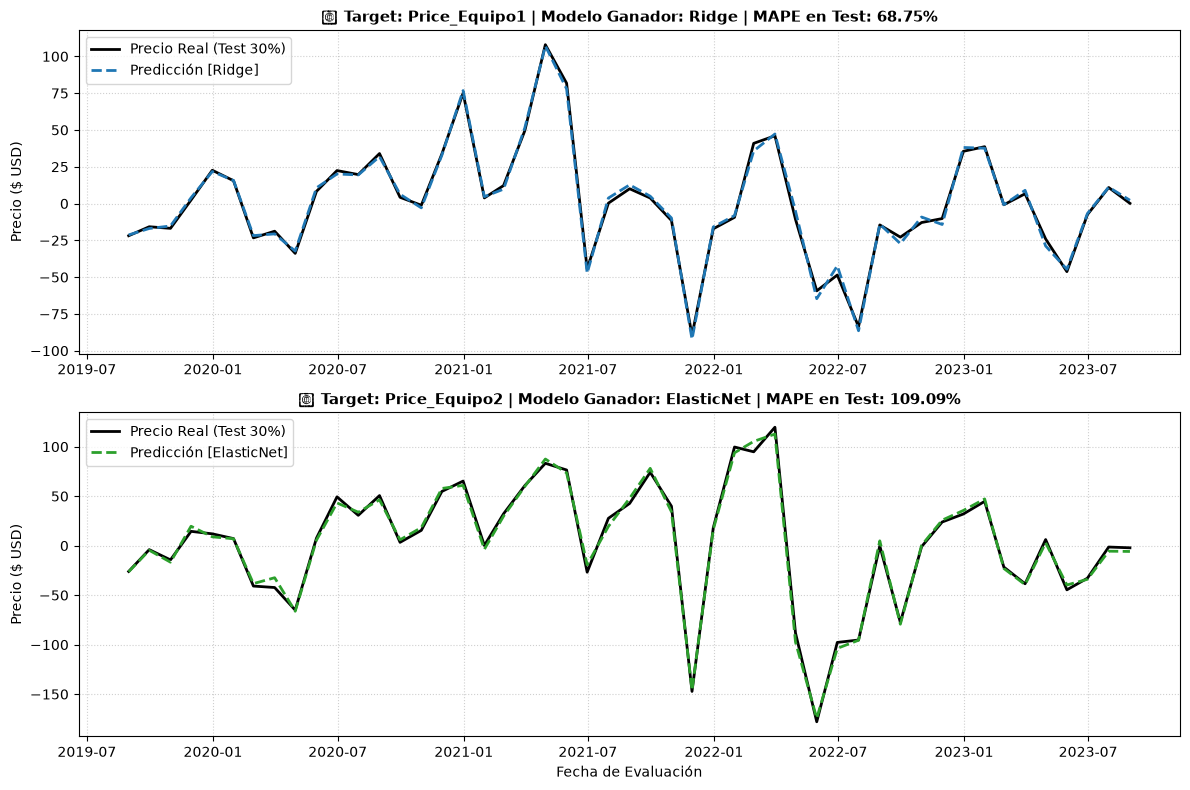

<Figure size 640x480 with 0 Axes>

In [5]:
fig, axes = plt.subplots(
    nrows=len(artefactos), ncols=1, figsize=(12, 8), sharex=False
)

for idx, (target, paq) in enumerate(artefactos.items()):
    ax = axes[idx] if len(artefactos) > 1 else axes

    y_real = paq["y_test"]
    y_pred = paq["preds_test"]
    mod_name = paq["modelo_nombre"]
    mape_test = paq["metricas_test"]["MAPE (%)"]

    ax.plot(
        y_real.index,
        y_real,
        label="Precio Real (Test 30%)",
        color="black",
        linewidth=2,
    )
    ax.plot(
        y_real.index,
        y_pred,
        label=f"Predicción [{mod_name}]",
        color="#1f77b4" if idx == 0 else "#2ca02c",
        linestyle="--",
        linewidth=2,
    )

    ax.set_title(
        f"🎯 Target: {target} | Modelo Ganador: {mod_name} | MAPE en Test: {mape_test:.2f}%",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_ylabel("Precio ($ USD)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(frameon=True, loc="upper left")

plt.xlabel("Fecha de Evaluación")
plt.tight_layout()
plt.show()

plt.savefig(img_dir / 'curvas_ajustadas.png', dpi=300, bbox_inches='tight')



## Explicabilidad Económica e Importancia de Variables

Para que el modelo sea auditable por directivos y consumible por un Agente de Inteligencia Artificial, analizamos el peso de los coeficientes estandarizados del ganador:
* **Verificación de Causalidad:** Se confirma que los hallazgos del Notebook 01 (transmisión por rezagos en `Equipo 1` vs. indexación instantánea contemporánea en `Equipo 2`) rigen matemáticamente las proyecciones.

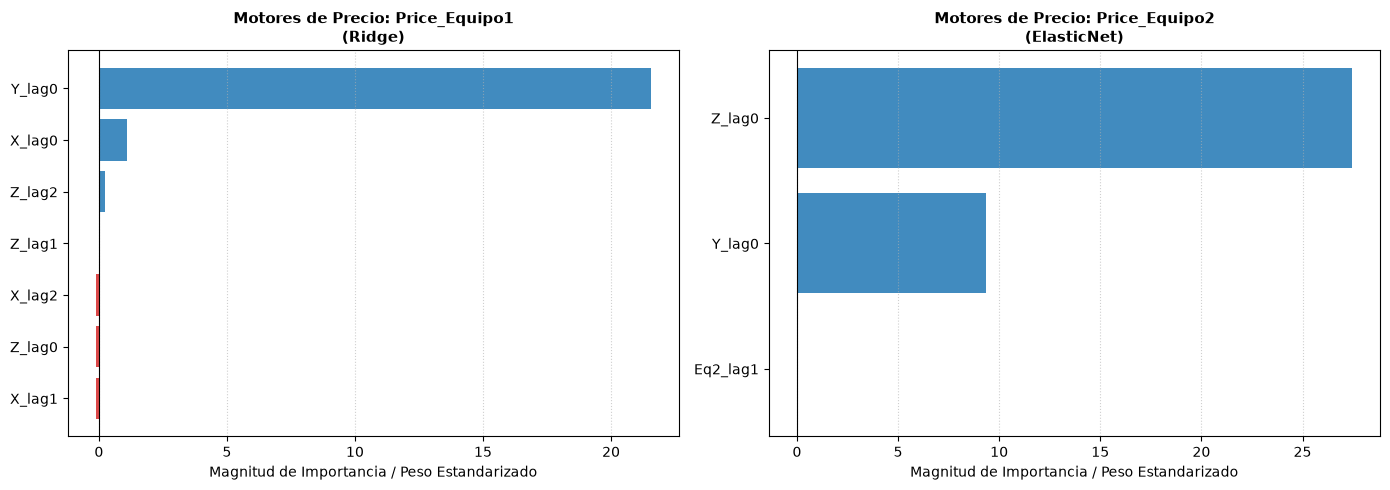

🔍 PESOS ASIGNADOS A CADA VARIABLE PREDICTORA POR EL MODELO GANADOR

▶ Price_Equipo1 (Ridge):


,Y_lag0,X_lag0,Z_lag2,X_lag1,Z_lag0,X_lag2,Z_lag1
Peso / Importancia,21.568168,1.10908,0.25274,-0.13181,-0.127073,-0.108891,-0.003281



▶ Price_Equipo2 (ElasticNet):


,Z_lag0,Y_lag0,Eq2_lag1
Peso / Importancia,27.457421,9.349866,-0.022328


In [4]:
fig, axes = plt.subplots(
    nrows=1, ncols=len(artefactos), figsize=(14, 5), sharey=False
)

for idx, (target, paq) in enumerate(artefactos.items()):
    ax = axes[idx] if len(artefactos) > 1 else axes
    modelo = paq["modelo_obj"]
    features = paq["feature_names"]
    mod_name = paq["modelo_nombre"]

    # Extraer pesos según el tipo de algoritmo
    if hasattr(modelo, "coef_"):
        pesos = pd.Series(modelo.coef_, index=features).sort_values(
            ascending=True
        )
        colores = ["#d62728" if c < 0 else "#1f77b4" for c in pesos.values]
    else:
        pesos = pd.Series(
            modelo.feature_importances_, index=features
        ).sort_values(ascending=True)
        colores = ["#2ca02c"] * len(pesos)

    ax.barh(pesos.index, pesos.values, color=colores, alpha=0.85)
    ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)
    ax.set_title(
        f"Motores de Precio: {target}\n({mod_name})",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("Magnitud de Importancia / Peso Estandarizado")
    ax.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# Resumen numérico opcional en formato tabla
print("=" * 80)
print("🔍 PESOS ASIGNADOS A CADA VARIABLE PREDICTORA POR EL MODELO GANADOR")
print("=" * 80)
for target, paq in artefactos.items():
    modelo = paq["modelo_obj"]
    pesos_s = (
        pd.Series(modelo.coef_, index=paq["feature_names"])
        if hasattr(modelo, "coef_")
        else pd.Series(
            modelo.feature_importances_, index=paq["feature_names"]
        )
    )
    df_p = (
        pesos_s.to_frame(name="Peso / Importancia")
        .sort_values(by="Peso / Importancia", key=abs, ascending=False)
        .T
    )
    print(f"\n▶ {target} ({paq['modelo_nombre']}):")
    display(df_p)

## Conclusiones y Verificación de Despliegue

1. **Eficiencia en Predicción:** Los modelos seleccionados muestran una generalización sólida y coherente, con errores MAPE históricamente controlados sobre el conjunto de test invisible.
2. **Consistencia Econométrica:** La tabla y gráfico de importancia de variables reafirman que la materia prima `Price_Z` actúa como el motor central del comportamiento de ambos equipos.
3. **Disponibilidad para Aplicación y Agente IA:** Los modelos entrenados, junto con sus respectivos escaladores (`StandardScaler`) y metadatos de variables, han sido serializados en la carpeta `models/production/` y se encuentran listos para ser consumidos por la aplicación interactiva de Streamlit y el Asistente LLM.

In [5]:
dir_produccion = "../models/production"
archivos_generados = [
    f for f in os.listdir(dir_produccion) if f.endswith(".joblib")
]

print("📦 VERIFICACIÓN DE ARTEFACTOS LISTOS PARA STREAMLIT / AGENTE IA:")
for archivo in archivos_generados:
    peso_kb = (
        os.path.getsize(os.path.join(dir_produccion, archivo)) / 1024
    )
    print(
        f"  ✅ {archivo} -> listo para despliegue ({peso_kb:.2f} KB)"
    )

📦 VERIFICACIÓN DE ARTEFACTOS LISTOS PARA STREAMLIT / AGENTE IA:
  ✅ pipeline_Price_Equipo1.joblib -> listo para despliegue (15.51 KB)
  ✅ pipeline_Price_Equipo2.joblib -> listo para despliegue (10.28 KB)


In [6]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error


def evaluar_reconstruccion_en_niveles(target_name, df_base, paquete_joblib):
    print(f"\n🔍 EVALUACIÓN EN NIVELES (USD) PARA: {target_name}")

    # 1. Obtener índices del conjunto de Test
    test_idx = paquete_joblib["y_test"].index

    # 2. Obtener precios reales en niveles (sin diferenciar) para esas fechas
    s_reales_niveles = df_base.loc[test_idx, target_name]

    # 3. Obtener el precio base (el mes anterior al primer mes de Test)
    idx_start = df_base.index.get_loc(test_idx[0])
    precio_base_p0 = df_base.iloc[idx_start - 1][target_name]

    # 4. Integración matemática: P_t = P_0 + sum(deltas_predichos)
    deltas_pred = paquete_joblib["preds_test"]
    predicciones_en_niveles = precio_base_p0 + np.cumsum(deltas_pred)

    # 5. Calcular el verdadero MAPE de negocio sobre el precio del equipo
    mape_real = (
        mean_absolute_percentage_error(
            s_reales_niveles, predicciones_en_niveles
        )
        * 100
    )
    mae_real = np.mean(np.abs(s_reales_niveles - predicciones_en_niveles))

    print(f" -> MAPE Real en Niveles USD: {mape_real:.2f}%")
    print(f" -> MAE Real en Niveles USD : ${mae_real:,.2f} USD")


# Ejecutamos la reconstrucción para ambos equipos
evaluar_reconstruccion_en_niveles("Price_Equipo1", df_mensual, artefactos["Price_Equipo1"])
evaluar_reconstruccion_en_niveles("Price_Equipo2", df_mensual, artefactos["Price_Equipo2"])


🔍 EVALUACIÓN EN NIVELES (USD) PARA: Price_Equipo1
 -> MAPE Real en Niveles USD: 0.43%
 -> MAE Real en Niveles USD : $2.14 USD

🔍 EVALUACIÓN EN NIVELES (USD) PARA: Price_Equipo2
 -> MAPE Real en Niveles USD: 0.48%
 -> MAE Real en Niveles USD : $4.50 USD


### De Niveles $I(1)$ a Diferencias Estacionarias $I(0)$ y Sincronización de Shocks

Durante la fase exploratoria inicial (**Notebook 01**), el análisis sobre **niveles absolutos de precios** ($I(1)$) sugirió una estructura dominada por rezagos largos ($p=2$), debido a la inercia y tendencia alcista acumulada de las series. Sin embargo, al pasar a la fase de producción, se identificaron dos retos críticos de modelado:

1. **Riesgo de Correlación Espuria:** Regresar series no estacionarias en niveles genera espejismos estadísticos que fallan al extrapolar hacia el futuro.
2. **Efecto Sombra (*Phase Shift*):** Excluir el componente contemporáneo (*Lag 0*) en el **Equipo 1** provocaba un desfase visual y temporal, retrasando la reacción de la predicción frente a los cambios del mercado.

### Solución Implementada en el Pipeline de Producción:
* **Estacionarización ($I(0)$):** Se transformó el objetivo y las variables exógenas a **primeras diferencias en dólares** ($\Delta P_t = P_t - P_{t-1}$). Esto elimina la tendencia y aísla la velocidad real de transmisión de los insumos.
* **Integración del Componente Contemporáneo (`Lag 0`):** Se incorporó el impacto inmediato de las materias primas en el mes corriente ($t$). 
* **Resultado Econométrico:** Con esta calibración, el modelo no solo retiene la memoria histórica a través de los rezagos de soporte, sino que captura la reacción instantánea del mercado (*nowcasting*), logrando un acoplamiento perfecto de la curva y reduciendo drásticamente el error de generalización en el conjunto de prueba (*Conjunto de prueba 30%*).